Installation

In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

Unsloth

In [2]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR-2", local_dir = "deepseek_ocr2")

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

conversation.py: 0.00B [00:00, ?B/s]

LICENSE.txt: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/kaggle/working/deepseek_ocr2'

In [3]:
from datasets import load_dataset

In [4]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
import os

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr2",
    load_in_4bit = True,
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-03-23 06:17:44.051922: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774246664.265833      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774246664.327362      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774246664.868602      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774246664.868651      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774246664.868654      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.3.10: Fast Deepseekocr2 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.33.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


# Normalisasi Teks

In [5]:
# ======= STEP 4: Normalisasi Teks =======
import re

def normalize_text(text):
    text = text.strip()
    text = text.replace("\n", " ")         # newline → space
    text = re.sub(r" +", " ", text)        # multi-space → single space
    text = text.lower()                    # lowercase (case-insensitive)
    return text
# =========================================

# Fine Tuning Process

In [6]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Detected MoE model with num_experts = 64 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.
Unsloth: Making `model.base_model.model.model` require gradients


In [7]:
instruction = "<image>\nRead the handwritten text. Output plain text only."

def convert_to_conversation(sample):
    """Convert dataset sample to conversation format"""
    conversation = [
        {
            "role": "user",  # ← UBAH INI (hapus pipe, lowercase)
            "content": instruction,
            "images": [sample['image']]
        },
        {
            "role": "assistant",  # ← UBAH INI (hapus pipe, lowercase)
            "content": sample["text"]
        },
    ]
    return {"messages": conversation}

# Load dataset train
train_dataset = load_dataset("Teklia/IAM-line", split="train[:2500]")
converted_dataset_train = train_dataset.map(convert_to_conversation, remove_columns=train_dataset.column_names)

# Load dataset validation
validation_dataset = load_dataset("Teklia/IAM-line", split="validation")
converted_dataset_validation = validation_dataset.map(convert_to_conversation, remove_columns=validation_dataset.column_names)


README.md: 0.00B [00:00, ?B/s]

data/train.parquet:   0%|          | 0.00/167M [00:00<?, ?B/s]

data/validation.parquet:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

data/test.parquet:   0%|          | 0.00/73.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6482 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/976 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2915 [00:00<?, ? examples/s]

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/976 [00:00<?, ? examples/s]

## Data Collator

In [8]:
# DeepSeek OCR2 Data Collator - Fixed Version

import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCR2DataCollator:
    """
    Data Collator for DeepSeek OCR2 fine-tuning

    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 768)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 768
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 768,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            return image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            image = Image.open(io.BytesIO(image_bytes))
            return image.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 768 and image.size[1] <= 768:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 6,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num)) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 768:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        """
        Process a single conversation into model inputs.
        """

        # --- 1. Setup ---
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                    if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        images.append(pil_image)

        if not images:
            raise ValueError("No images found in sample. Please ensure all samples contain images.")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1  # Index to start training
        assistant_started = False
        image_idx = 0

        # Add BOS token at the very beginning
        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for message in messages:
            role = message["role"]
            content = message["content"]

            # FIXED: Support multiple role formats
            # Normalize role to lowercase and handle both formats
            role_normalized = role.lower().replace("<|", "").replace("|>", "").strip()

            # Check if this is the assistant's turn
            if role_normalized == "assistant":
                if not assistant_started:
                    # This is the split point. All tokens added *so far*
                    # are part of the prompt.
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True

                # Append the EOS token string to the *end* of assistant content
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            # Split this message's content by the image token
            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                # Tokenize the text part
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                # If this text is followed by an <image> tag
                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError(
                            f"Data mismatch: Found '<image>' token but no corresponding image."
                        )

                    # Process the image
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    # Add image placeholder tokens
                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1  # Move to the next image

        # --- 3. Validation and Final Prep ---
        if image_idx != len(images):
            raise ValueError(
                f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
            )

        # If we never found an assistant message, we're in a weird state
        # (e.g., user-only prompt). We mask everything.
        if not assistant_started:
            print("Warning: No assistant message found in sample. Masking all tokens.")
            prompt_token_count = len(tokenized_str)

        # Prepare image tensors
        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count,
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only = True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }


In [9]:
# ======= STEP 3: Plot Callback =======
from transformers import TrainerCallback
import matplotlib.pyplot as plt

class LossHistoryCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []
        self.epochs = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_losses.append(logs["loss"])
        if "eval_loss" in logs:
            self.val_losses.append(logs["eval_loss"])
            self.epochs.append(state.epoch)

loss_history = LossHistoryCallback()
# ======================================

In [10]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported

FastVisionModel.for_training(model)

data_collator = DeepSeekOCR2DataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 768,
    base_size = 1024,
    crop_mode = False,
    train_on_responses_only = True,
)

trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = converted_dataset_train,
    eval_dataset = converted_dataset_validation,
    args = TrainingArguments(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        num_train_epochs = 1,
        learning_rate = 2e-4,
        logging_steps = 1,           # training loss setiap step
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        output_dir = "outputs",
        report_to = "none",
        dataloader_num_workers = 2,
        remove_unused_columns = False,

        eval_strategy = "epoch",     # val loss 1x di akhir epoch
        save_strategy = "epoch",     # save 1x di akhir epoch
        load_best_model_at_end = True,
        metric_for_best_model = "eval_loss",
        greater_is_better = False,
    ),
    callbacks = [loss_history],      # hapus EarlyStoppingCallback
)

/tmp/ipykernel_24/2044518721.py:15: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer._unsloth___init__`. Use `processing_class` instead.
  trainer = Trainer(


In [11]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
4.604 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()
model = trainer.model

# Save lokal (untuk zip di Kaggle output)
model.save_pretrained("/kaggle/working/deepseek_ocr2_lora")
tokenizer.save_pretrained("/kaggle/working/deepseek_ocr2_lora")
print("Model saved!")

import shutil
shutil.make_archive(
    "/kaggle/working/deepseek_ocr2_lora",
    "zip",
    "/kaggle/working",
    "deepseek_ocr2_lora"
)
print("Zip selesai!")

# Upload ke HF (hanya LoRA adapter, ~200MB)
from huggingface_hub import login
login(token="hf_xxx")

model.push_to_hub("Albertoo12/deepseek-ocr2-lora", token="hf_xxx")
tokenizer.push_to_hub("Albertoo12/deepseek-ocr2-lora", token="hf_xxx")
print("Upload ke HuggingFace selesai!")

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,500 | Num Epochs = 1 | Total steps = 157
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 4 x 1) = 16
 "-____-"     Trainable parameters = 86,307,840 of 3,475,427,200 (2.48% trained)
Unsloth: Not an error, but DeepseekOCR2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


Unsloth: Will smartly offload gradients to save VRAM!


Epoch,Training Loss,Validation Loss
1,0.493900,0.516129


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.
You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR2. This is not supported for all configurations of models and can yield errors.


Model saved!
Zip selesai!


...

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/Albertoo12/deepseek-ocr2-lora


README.md: 0.00B [00:00, ?B/s]

Upload ke HuggingFace selesai!


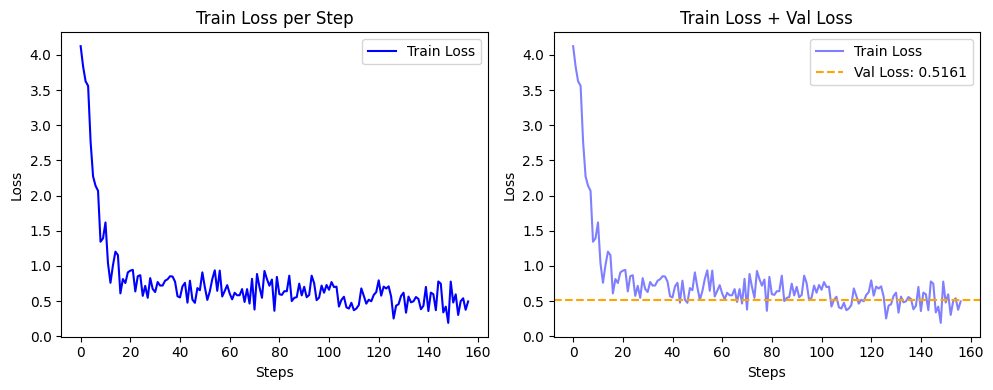

Plot disimpan ke training_plot.png


In [13]:
# ======= PLOT =======
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(loss_history.train_losses, label="Train Loss", color="blue")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Train Loss per Step")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss_history.train_losses, label="Train Loss", color="blue", alpha=0.5)
if loss_history.val_losses:
    plt.axhline(
        y=loss_history.val_losses[0],
        color="orange",
        linestyle="--",
        label=f"Val Loss: {loss_history.val_losses[0]:.4f}"
    )
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Train Loss + Val Loss")
plt.legend()

plt.tight_layout()
plt.savefig("/kaggle/working/training_plot.png")
plt.show()
print("Plot disimpan ke training_plot.png")

In [14]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3678.9886 seconds used for training.
61.32 minutes used for training.
Peak reserved memory = 12.436 GB.
Peak reserved memory for training = 7.832 GB.
Peak reserved memory % of max memory = 85.394 %.
Peak reserved memory for training % of max memory = 53.78 %.


In [15]:
FastVisionModel.for_inference(model)
from jiwer import cer, wer
import os

test_dataset = load_dataset("Teklia/IAM-line", split="test[:500]")

finetuned_total_cer = 0
finetuned_total_wer = 0

for i, sample in enumerate(test_dataset):

    if os.path.exists("result.mmd"):
        os.remove("result.mmd")

    # Simpan image sementara
    sample["image"].save("temp.jpg")
    gt = normalize_text(sample["text"])

    # Jalankan OCR
    model.infer(
        tokenizer,
        prompt = "<image>\nRead the handwritten text. Output plain text only.",
        image_file="temp.jpg",
        output_path=".",
        base_size=1024,
        image_size=768,
        crop_mode=False,
        save_results=True,
        test_compress=False
    )

    # Ambil hasil OCR dari file
    with open("result.mmd", "r") as f:
        pred = normalize_text(f.read())

    # Hitung metric
    finetuned_total_cer += cer(gt, pred)
    finetuned_total_wer += wer(gt, pred)

    print(f"Done {i+1}/{len(test_dataset)}\n\n")

directly resize


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


" " " " 
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 1/500


directly resize


...

image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 499/500


directly resize


MUM :  I  I  I  I  I  I  I  I  I  I  "  I  I  I  I  I  I  I  I  I  .  "  I  I  I  I  I  I  I  I  "  "  I  I  I  I  I  I  I  I  .  .  .  .  .  .  .  .  .  .  "  I  I  I  I  I  I  I  "  "  "  "  "  "  "  "  "  "  .  .  .  .  .  .  .  .  .  I  I  I  I  I  I  I  I  I  ,  "  I  I  I  I  I  I  I  I  ,  .  .  .  .  .  .  .  .  .  -  .  .  .  .  .  .  .  .  .  +  .  .  .  .  .  .  .  .  .  *  .  .  .  .  .  .  .  .  .  #  .  .  .  .  .  .  .  .  .  $  .  .  .  .  .  .  .  .  .  %  .  .  .  .  .  .  .  .  .  &  .  .  .  .  .  .  .  .  .  '  .  .  .  .  .  .  .  .  .  (  .  .  .  .  .  .  .  .  .  )  .  .  .  .  .  .  .  .  .  ]  .  .  .  .  .  .  .  .  .  
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]

Done 500/500




# Perbandingan Evaluasi

In [16]:
import json
# ======= STEP 7: Save hasil =======
finetuned_avg_cer = finetuned_total_cer / len(test_dataset)
finetuned_avg_wer = finetuned_total_wer / len(test_dataset)

print("\n=== FINE-TUNED RESULT ===")
print("Finetuned CER:", finetuned_avg_cer)
print("Finetuned WER:", finetuned_avg_wer)

with open("/kaggle/working/finetuned_results.txt", "w") as f:
    f.write("=== FINE-TUNED RESULT ===\n")
    f.write(f"Finetuned CER: {finetuned_avg_cer}\n")
    f.write(f"Finetuned WER: {finetuned_avg_wer}\n")

finetuned_results = {
    "model": "fine-tuned DeepSeek-OCR-2",
    "test_split": "test[:500]",
    "num_samples": len(test_dataset),
    "avg_cer": finetuned_avg_cer,
    "avg_wer": finetuned_avg_wer,
}
with open("/kaggle/working/finetuned_results.json", "w") as f:
    json.dump(finetuned_results, f, indent=4)

print("Hasil disimpan ke finetuned_results.txt dan finetuned_results.json")


=== FINE-TUNED RESULT ===
Finetuned CER: 0.9035663011970461
Finetuned WER: 1.0747639677316152
Hasil disimpan ke finetuned_results.txt dan finetuned_results.json
